In [1]:
# %%
# ============================================
# Diagnostic Notebook: Analyse Nested-CV Results (A vs B vs A+B)
# Inputs:
# - results_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
# - predictions_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
# - best_params_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
#
# Outputs:
# - Plots + summary tables for performance, ROC/PR, calibration, confusion
# - Sanity checks for leakage and fold composition
# ============================================

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
)

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data"
DERIVED_ROOT = DATA_ROOT / "derived"
OUT_DIR = DERIVED_ROOT / "models"

RESULTS_PATH = OUT_DIR / "results_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv"
PRED_PATH    = OUT_DIR / "predictions_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv"
PARAMS_PATH  = OUT_DIR / "best_params_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv"

print("RESULTS:", RESULTS_PATH)
print("PRED:", PRED_PATH)
print("PARAMS:", PARAMS_PATH)

RESULTS: /srv/scratch/z5718315/ketamine-project/data/derived/models/results_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
PRED: /srv/scratch/z5718315/ketamine-project/data/derived/models/predictions_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
PARAMS: /srv/scratch/z5718315/ketamine-project/data/derived/models/best_params_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv


In [2]:
# %%
# ============================================
# Diagnostic Notebook: Analyse Nested-CV Results (A vs B vs A+B)
# Inputs:
# - results_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
# - predictions_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
# - best_params_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
#
# Outputs:
# - Plots + summary tables for performance, ROC/PR, calibration, confusion
# - Sanity checks for leakage and fold composition
# ============================================

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
)

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data"
DERIVED_ROOT = DATA_ROOT / "derived"
OUT_DIR = DERIVED_ROOT / "models"

RESULTS_PATH = OUT_DIR / "results_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv"
PRED_PATH    = OUT_DIR / "predictions_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv"
PARAMS_PATH  = OUT_DIR / "best_params_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv"

print("RESULTS:", RESULTS_PATH)
print("PRED:", PRED_PATH)
print("PARAMS:", PARAMS_PATH)

RESULTS: /srv/scratch/z5718315/ketamine-project/data/derived/models/results_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
PRED: /srv/scratch/z5718315/ketamine-project/data/derived/models/predictions_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv
PARAMS: /srv/scratch/z5718315/ketamine-project/data/derived/models/best_params_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv


In [4]:
# ============================================
# 1) Load data
# ============================================

assert RESULTS_PATH.exists(), f"Missing file: {RESULTS_PATH}"
assert PRED_PATH.exists(), f"Missing file: {PRED_PATH}"
assert PARAMS_PATH.exists(), f"Missing file: {PARAMS_PATH}"

folds  = pd.read_csv(RESULTS_PATH)
preds  = pd.read_csv(PRED_PATH)
params = pd.read_csv(PARAMS_PATH)

print("folds shape:", folds.shape)
print("preds shape:", preds.shape)
print("params shape:", params.shape)

display(folds.head())
display(preds.head())
display(params.head())

folds shape: (15, 11)
preds shape: (828, 6)
params shape: (15, 15)


,model,fold,n_test,n_test_subjects,accuracy,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,A_bandpower_epoch,1,56,2,0.696429,0.696429,0.820153,16.0,12.0,5.0,23.0
1,A_bandpower_epoch,2,55,2,0.818182,0.821429,0.870370,18.0,10.0,0.0,27.0
2,A_bandpower_epoch,3,54,2,0.870370,0.876552,0.951724,23.0,6.0,1.0,24.0
3,A_bandpower_epoch,4,56,2,0.625000,0.625000,0.913265,28.0,0.0,21.0,7.0
4,A_bandpower_epoch,5,55,2,0.509091,0.509259,0.551587,14.0,14.0,13.0,14.0


,model,fold,subject_id,y_true,y_proba,y_pred
0,A_bandpower_epoch,1,249,0,0.099539,0
1,A_bandpower_epoch,1,249,0,0.336195,0
2,A_bandpower_epoch,1,249,0,0.260752,0
3,A_bandpower_epoch,1,249,0,0.095791,0
4,A_bandpower_epoch,1,249,0,0.095848,0


,model,fold,n_iter,best_score_inner,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,rf__max_depth,rf__max_features,rf__min_samples_leaf,rf__min_samples_split,rf__n_estimators,pca_n_components
0,A_bandpower_epoch,1,10,0.712815,10.0,0.2,1.0,10.0,344.0,NaN,NaN,NaN,NaN,NaN,NaN
1,A_bandpower_epoch,2,10,0.676887,NaN,0.2,2.0,10.0,734.0,NaN,NaN,NaN,NaN,NaN,NaN
2,A_bandpower_epoch,3,10,0.658069,20.0,sqrt,4.0,9.0,371.0,NaN,NaN,NaN,NaN,NaN,NaN
3,A_bandpower_epoch,4,10,0.714680,10.0,0.1,1.0,3.0,522.0,NaN,NaN,NaN,NaN,NaN,NaN
4,A_bandpower_epoch,5,10,0.776330,20.0,0.2,2.0,8.0,318.0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# %%
# ============================================
# 2) Integrity checks (minimal but strict)
# ============================================

req_folds = {"model","fold","accuracy","balanced_accuracy","roc_auc","n_test","n_test_subjects"}
req_preds = {"model","fold","subject_id","y_true","y_proba","y_pred"}

missing_folds = req_folds - set(folds.columns)
missing_preds = req_preds - set(preds.columns)

assert not missing_folds, f"folds missing columns: {missing_folds}"
assert not missing_preds, f"preds missing columns: {missing_preds}"

# y_true should be binary
assert set(np.unique(preds["y_true"])) <= {0,1}, "y_true not binary?"
assert set(np.unique(preds["y_pred"])) <= {0,1}, "y_pred not binary?"

# probability bounds
if not ((preds["y_proba"] >= -1e-9) & (preds["y_proba"] <= 1+1e-9)).all():
    bad = preds.loc[~((preds["y_proba"] >= 0) & (preds["y_proba"] <= 1))].head()
    raise RuntimeError(f"Found y_proba outside [0,1]. Example:\n{bad}")

print("OK: basic integrity checks passed")

# Fold coverage check: each (model, fold) should appear in folds
print("folds per model:", folds.groupby("model")["fold"].nunique().to_dict())
print("pred rows per model:", preds.groupby("model").size().to_dict())

OK: basic integrity checks passed
folds per model: {'A_bandpower_epoch': 5, 'B_wpli_edges_epoch_sliding': 5, 'C_AplusB_epoch_sliding': 5}
pred rows per model: {'A_bandpower_epoch': 276, 'B_wpli_edges_epoch_sliding': 276, 'C_AplusB_epoch_sliding': 276}


In [6]:
# %%
# ============================================
# 3) Quick performance summary tables
# ============================================

summary = (
    folds.groupby("model")[["accuracy","balanced_accuracy","roc_auc"]]
    .agg(["mean","std","min","max"])
    .round(4)
)
display(summary)

# Also show per-fold values to see variance
display(folds.sort_values(["model","fold"]))

accuracy                         balanced_accuracy  \
                               mean     std     min     max              mean   
model                                                                           
A_bandpower_epoch            0.7038  0.1458  0.5091  0.8704            0.7057   
B_wpli_edges_epoch_sliding   0.5290  0.0757  0.4182  0.6071            0.5294   
C_AplusB_epoch_sliding       0.6385  0.1225  0.4909  0.7778            0.6380   

                                                   roc_auc                  \
                               std     min     max    mean     std     min   
model                                                                        
A_bandpower_epoch           0.1481  0.5093  0.8766  0.8214  0.1586  0.5516   
B_wpli_edges_epoch_sliding  0.0792  0.4147  0.6071  0.5355  0.0682  0.4339   
C_AplusB_epoch_sliding      0.1213  0.4914  0.7738  0.7555  0.0936  0.6349   

                                    
                               max  
model                               
A_bandpower_epoch           0.9517  
B_wpli_edges_epoch_sliding  0.6020  
C_AplusB_epoch_sliding      0.8841

,model,fold,n_test,n_test_subjects,accuracy,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,A_bandpower_epoch,1,56,2,0.696429,0.696429,0.820153,16.0,12.0,5.0,23.0
1,A_bandpower_epoch,2,55,2,0.818182,0.821429,0.870370,18.0,10.0,0.0,27.0
2,A_bandpower_epoch,3,54,2,0.870370,0.876552,0.951724,23.0,6.0,1.0,24.0
3,A_bandpower_epoch,4,56,2,0.625000,0.625000,0.913265,28.0,0.0,21.0,7.0
4,A_bandpower_epoch,5,55,2,0.509091,0.509259,0.551587,14.0,14.0,13.0,14.0
5,B_wpli_edges_epoch_sliding,1,56,2,0.607143,0.607143,0.602041,21.0,7.0,15.0,13.0
6,B_wpli_edges_epoch_sliding,2,55,2,0.509091,0.505952,0.558201,19.0,9.0,18.0,9.0
7,B_wpli_edges_epoch_sliding,3,54,2,0.592593,0.601379,0.582069,14.0,15.0,7.0,18.0
8,B_wpli_edges_epoch_sliding,4,56,2,0.517857,0.517857,0.501276,12.0,16.0,11.0,17.0
9,B_wpli_edges_epoch_sliding,5,55,2,0.418182,0.414683,0.433862,17.0,11.0,21.0,6.0


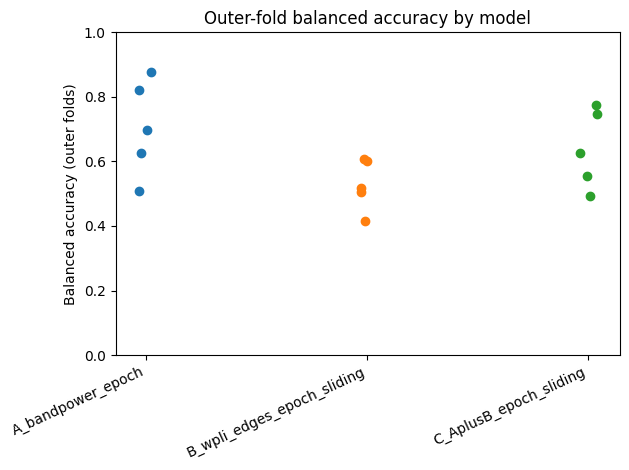

In [7]:
# %%
# ============================================
# 4) Plot: per-fold balanced accuracy (dot plot)
# ============================================

models = sorted(folds["model"].unique())
plt.figure()
for i, m in enumerate(models):
    vals = folds.loc[folds["model"] == m, "balanced_accuracy"].to_numpy()
    x = np.full_like(vals, i, dtype=float) + (np.random.rand(len(vals)) - 0.5) * 0.08
    plt.scatter(x, vals)

plt.xticks(range(len(models)), models, rotation=25, ha="right")
plt.ylabel("Balanced accuracy (outer folds)")
plt.ylim(0, 1)
plt.title("Outer-fold balanced accuracy by model")
plt.tight_layout()
plt.show()

In [9]:
# %%
# ============================================
# 5) Confusion matrices (aggregate across all outer-fold predictions)
# ============================================

def agg_confusion(df_model: pd.DataFrame) -> np.ndarray:
    return confusion_matrix(df_model["y_true"], df_model["y_pred"], labels=[0,1])

for m in models:
    pm = preds[preds["model"] == m]
    cm = agg_confusion(pm)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n=== {m} ===")
    print("TN FP")
    print(cm[0])
    print("FN TP")
    print(cm[1])
    acc = (tp + tn) / np.sum(cm)
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    print(f"acc={acc:.3f} | sensitivity={sens:.3f} | specificity={spec:.3f}")


=== A_bandpower_epoch ===
TN FP
[99 42]
FN TP
[40 95]
acc=0.703 | sensitivity=0.704 | specificity=0.702

=== B_wpli_edges_epoch_sliding ===
TN FP
[83 58]
FN TP
[72 63]
acc=0.529 | sensitivity=0.467 | specificity=0.589

=== C_AplusB_epoch_sliding ===
TN FP
[97 44]
FN TP
[56 79]
acc=0.638 | sensitivity=0.585 | specificity=0.688


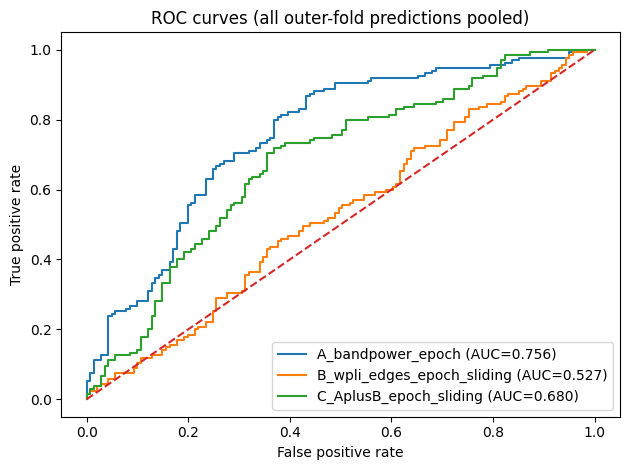

In [10]:
# %%
# ============================================
# 6) ROC curves (aggregate)
# Note: With grouped CV, this is still fine as a diagnostic.
# ============================================

plt.figure()

for m in models:
    pm = preds[preds["model"] == m]
    y_true = pm["y_true"].to_numpy()
    y_proba = pm["y_proba"].to_numpy()

    # Guard: ROC requires both classes present
    if len(np.unique(y_true)) < 2:
        print(f"Skipping ROC for {m}: only one class present in predictions")
        continue

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{m} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves (all outer-fold predictions pooled)")
plt.legend()
plt.tight_layout()
plt.show()

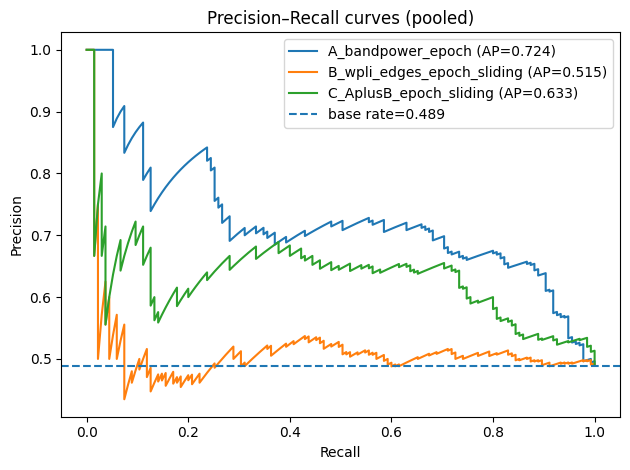

In [11]:
# %%
# ============================================
# 7) Precision–Recall curves (aggregate)
# Better when class imbalance exists
# ============================================

plt.figure()

for m in models:
    pm = preds[preds["model"] == m]
    y_true = pm["y_true"].to_numpy()
    y_proba = pm["y_proba"].to_numpy()

    if len(np.unique(y_true)) < 2:
        print(f"Skipping PR for {m}: only one class present in predictions")
        continue

    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    plt.plot(rec, prec, label=f"{m} (AP={ap:.3f})")

base_rate = preds["y_true"].mean()
plt.axhline(base_rate, linestyle="--", label=f"base rate={base_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curves (pooled)")
plt.legend()
plt.tight_layout()
plt.show()

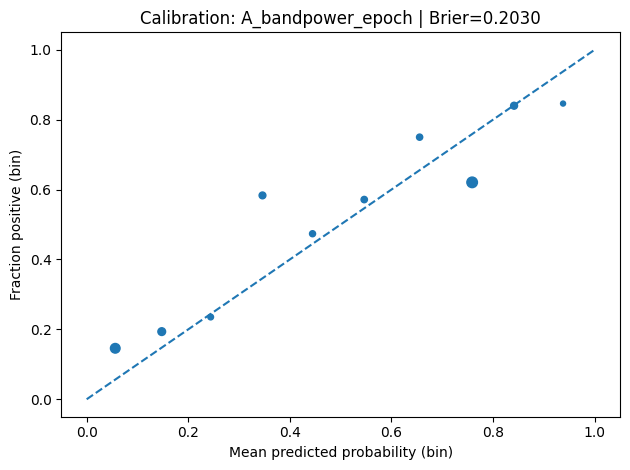

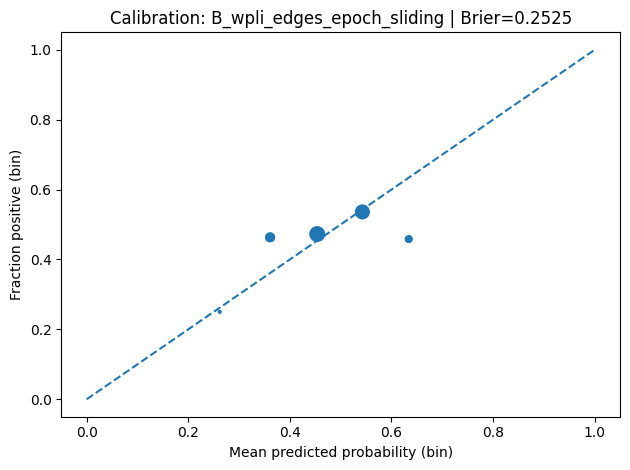

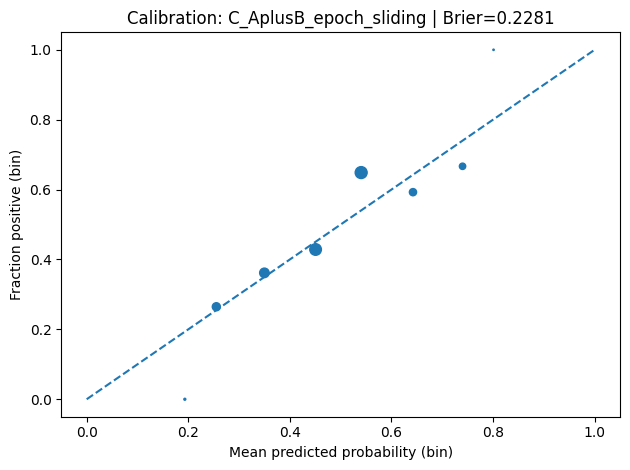

In [12]:
# %%
# ============================================
# 8) Calibration diagnostics (reliability curve + Brier score)
# This is purely diagnostic: RF probabilities are often miscalibrated.
# ============================================

def calibration_bins(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(y_prob, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)

    prob_mean = np.zeros(n_bins) * np.nan
    frac_pos = np.zeros(n_bins) * np.nan
    count = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        mask = idx == b
        count[b] = int(mask.sum())
        if count[b] > 0:
            prob_mean[b] = float(np.mean(y_prob[mask]))
            frac_pos[b] = float(np.mean(y_true[mask]))
    return prob_mean, frac_pos, count

for m in models:
    pm = preds[preds["model"] == m]
    y_true = pm["y_true"].to_numpy()
    y_prob = pm["y_proba"].to_numpy()

    if len(np.unique(y_true)) < 2:
        print(f"Skipping calibration for {m}: only one class present")
        continue

    brier = brier_score_loss(y_true, y_prob)
    prob_mean, frac_pos, count = calibration_bins(y_true, y_prob, n_bins=10)

    plt.figure()
    plt.plot([0,1],[0,1], linestyle="--")
    plt.scatter(prob_mean, frac_pos, s=np.maximum(count, 1))
    plt.xlabel("Mean predicted probability (bin)")
    plt.ylabel("Fraction positive (bin)")
    plt.title(f"Calibration: {m} | Brier={brier:.4f}")
    plt.tight_layout()
    plt.show()

In [13]:
# %%
# ============================================
# 9) Subject-level sanity check (optional but informative)
# Even if you "don't care", it can reveal if signal is consistent within subjects.
# We aggregate probabilities per (model, fold, subject) and compute metrics there.
# ============================================

def subject_agg_metrics(preds_model: pd.DataFrame) -> dict[str, float]:
    g = preds_model.groupby(["fold","subject_id"]).agg(
        y_true=("y_true", "first"),
        y_proba=("y_proba", "mean"),
    ).reset_index()

    y_true = g["y_true"].to_numpy()
    y_proba = g["y_proba"].to_numpy()
    y_pred = (y_proba >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    try:
        aucv = roc_auc_score(y_true, y_proba)
    except Exception:
        aucv = np.nan
    return {"acc": float(acc), "bacc": float(bacc), "auc": float(aucv), "n": int(len(g))}

from sklearn.metrics import accuracy_score, balanced_accuracy_score

rows = []
for m in models:
    pm = preds[preds["model"] == m].copy()
    met = subject_agg_metrics(pm)
    rows.append({"model": m, **met})

subj_summary = pd.DataFrame(rows).sort_values("bacc", ascending=False)
display(subj_summary)

/srv/scratch/z5718315/ketamine-project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/srv/scratch/z5718315/ketamine-project/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/srv/scratch/z5718315/ketamine-project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/srv/scratch/z5718315/ketamine-project/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/srv/scratch/z5718315/ketamine-project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classif

,model,acc,bacc,auc,n
2,C_AplusB_epoch_sliding,0.7,0.7,NaN,10
0,A_bandpower_epoch,0.6,0.6,NaN,10
1,B_wpli_edges_epoch_sliding,0.6,0.6,NaN,10


In [14]:
# %%
# ============================================
# 10) Hyperparameter stability: what gets picked per fold?
# ============================================

display(params.sort_values(["model","fold"]).head(30))

# Quick view of max_depth / max_features choices
if "max_depth" in params.columns:
    display(params.groupby("model")["max_depth"].value_counts(dropna=False))
if "max_features" in params.columns:
    display(params.groupby("model")["max_features"].value_counts(dropna=False))

,model,fold,n_iter,best_score_inner,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,rf__max_depth,rf__max_features,rf__min_samples_leaf,rf__min_samples_split,rf__n_estimators,pca_n_components
0,A_bandpower_epoch,1,10,0.712815,10.0,0.2,1.0,10.0,344.0,NaN,NaN,NaN,NaN,NaN,NaN
1,A_bandpower_epoch,2,10,0.676887,NaN,0.2,2.0,10.0,734.0,NaN,NaN,NaN,NaN,NaN,NaN
2,A_bandpower_epoch,3,10,0.658069,20.0,sqrt,4.0,9.0,371.0,NaN,NaN,NaN,NaN,NaN,NaN
3,A_bandpower_epoch,4,10,0.714680,10.0,0.1,1.0,3.0,522.0,NaN,NaN,NaN,NaN,NaN,NaN
4,A_bandpower_epoch,5,10,0.776330,20.0,0.2,2.0,8.0,318.0,NaN,NaN,NaN,NaN,NaN,NaN
5,B_wpli_edges_epoch_sliding,1,10,0.596467,NaN,NaN,NaN,NaN,NaN,10.0,0.05,2.0,9.0,519.0,100.0
6,B_wpli_edges_epoch_sliding,2,10,0.619426,NaN,NaN,NaN,NaN,NaN,10.0,0.2,4.0,6.0,324.0,100.0
7,B_wpli_edges_epoch_sliding,3,10,0.520503,NaN,NaN,NaN,NaN,NaN,20.0,sqrt,2.0,5.0,456.0,100.0
8,B_wpli_edges_epoch_sliding,4,10,0.615149,NaN,NaN,NaN,NaN,NaN,NaN,0.2,3.0,5.0,295.0,100.0
9,B_wpli_edges_epoch_sliding,5,10,0.609334,NaN,NaN,NaN,NaN,NaN,NaN,0.05,4.0,3.0,631.0,100.0


model                       max_depth
A_bandpower_epoch           10.0         2
                            20.0         2
                            NaN          1
B_wpli_edges_epoch_sliding  NaN          5
C_AplusB_epoch_sliding      NaN          5
Name: count, dtype: int64

model                       max_features
A_bandpower_epoch           0.2             3
                            0.1             1
                            sqrt            1
B_wpli_edges_epoch_sliding  NaN             5
C_AplusB_epoch_sliding      NaN             5
Name: count, dtype: int64

In [15]:
# %%
# ============================================
# 11) Error analysis: which subjects are consistently misclassified?
# ============================================

# Per subject + model: mean probability, true label, error rate
err = (
    preds.groupby(["model","subject_id"])
    .agg(
        y_true=("y_true","first"),
        mean_proba=("y_proba","mean"),
        pred_rate=("y_pred","mean"),
        n=("y_true","size"),
        err_rate=("y_pred", lambda x: float(np.mean(x != preds.loc[x.index, "y_true"]))),
    )
    .reset_index()
)

# Sort by error rate
display(err.sort_values(["model","err_rate"], ascending=[True, False]).head(30))

,model,subject_id,y_true,mean_proba,pred_rate,n,err_rate
4,A_bandpower_epoch,265,0,0.732214,0.916667,24,0.541667
7,A_bandpower_epoch,300,0,0.772985,1.000000,28,0.500000
3,A_bandpower_epoch,251,0,0.080522,0.000000,27,0.481481
9,A_bandpower_epoch,318,0,0.262836,0.071429,28,0.428571
5,A_bandpower_epoch,271,0,0.310622,0.178571,28,0.321429
1,A_bandpower_epoch,219,0,0.689881,0.800000,30,0.266667
8,A_bandpower_epoch,313,0,0.517558,0.655172,29,0.241379
2,A_bandpower_epoch,249,0,0.461546,0.406250,32,0.125000
0,A_bandpower_epoch,210,0,0.454851,0.520000,25,0.080000
6,A_bandpower_epoch,282,0,0.429072,0.440000,25,0.000000


In [16]:
# %%
# ============================================
# 12) Minimal "is B still degenerate?" diagnostic (variance check)
# This is only possible if you also kept feature tables. Here we infer from preds only:
# - If B performs at chance AND A performs > chance, could still be okay.
# But if B is exactly chance and calibration is weird, check the feature file.
# ============================================

chance = 0.5
tmp = folds.groupby("model")["balanced_accuracy"].mean().reset_index()
tmp["above_chance"] = tmp["balanced_accuracy"] - chance
display(tmp.sort_values("balanced_accuracy", ascending=False))

,model,balanced_accuracy,above_chance
0,A_bandpower_epoch,0.705734,0.205734
2,C_AplusB_epoch_sliding,0.637960,0.137960
1,B_wpli_edges_epoch_sliding,0.529403,0.029403
